In [57]:
import pathlib
import numpy as np
from skimage import io, color
from skimage.feature import hog
import matplotlib.pyplot as plt

In [58]:
def compute_Local_Binary_Pattern(image, P=8, R=1):

    lbp = np.zeros_like(image, dtype=np.uint8)

    # Offsets for 8 neighbors (clockwise from top-left)
    offsets = [(-1, -1), (-1, 0), (-1, 1),
               (0, 1), (1, 1), (1, 0),
               (1, -1), (0, -1)]
    
    # Pad image to handle borders
    padded = np.pad(image, pad_width=R, mode='edge')
    lbp = np.zeros_like(image, dtype=np.uint8)

    for i in range(R, padded.shape[0] - R):
        for j in range(R, padded.shape[1] - R):
            center = padded[i, j]
            code = 0
            for idx, (dy, dx) in enumerate(offsets):
                neighbor = padded[i + dy, j + dx]
                code |= (neighbor >= center) << (7 - idx)
            lbp[i - R, j - R] = code

    return lbp

In [59]:

def lbp_histogram(lbp_image):
    """
    Compute the histogram of an LBP image with 256 bins (0-255).
    Args:
        lbp_image (np.ndarray): 2D array of LBP values (uint8).
    Returns:
        np.ndarray: 1D array of length 256 with histogram counts.
    """
    #hist, _ = np.histogram(lbp_image.ravel(), bins=256, range=(0, 255))

    #plot histogram
    plt.figure(figsize=(8, 4))
    plt.hist(lbp_image.ravel(), bins=256, range=(0, 256), edgecolor='black')
    plt.xlim([0, 255])
    plt.xlabel("LBP Value")
    plt.ylabel("Frequency")
    plt.show()
    

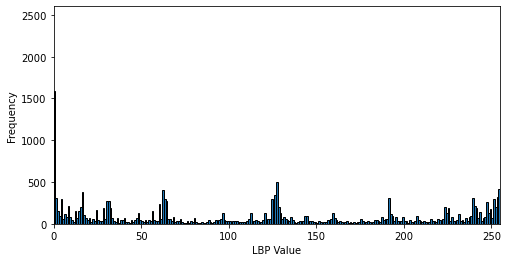

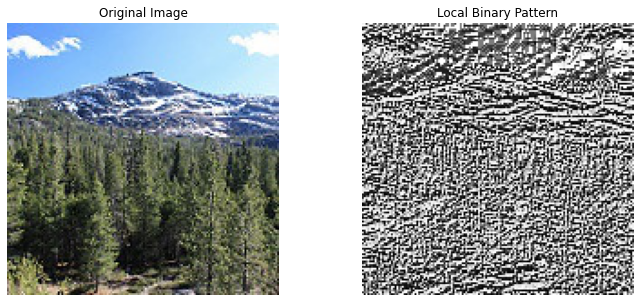

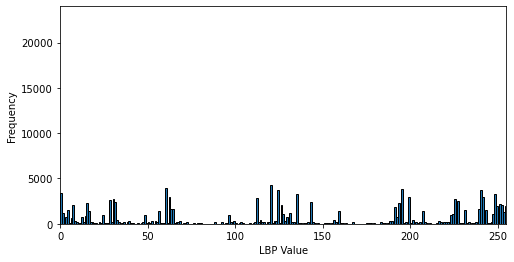

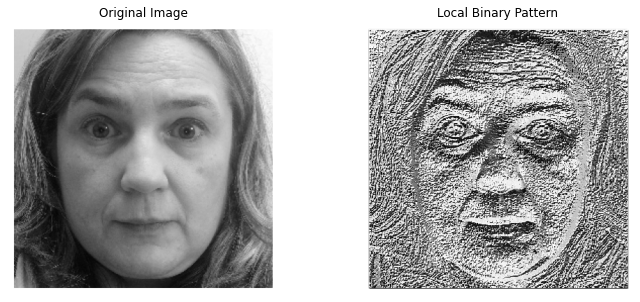

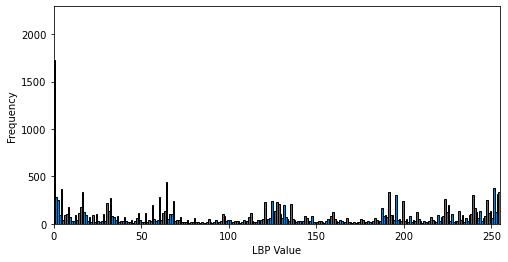

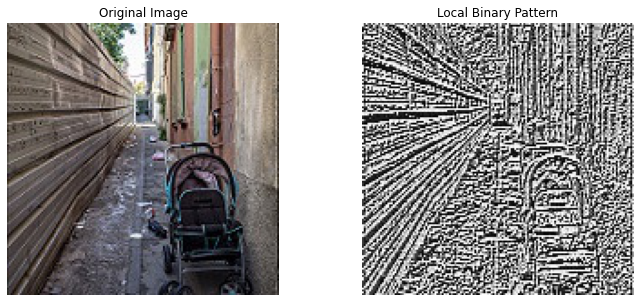

In [60]:
# Analyse the local binary patterns in images using HOG features

IMG_LIST = ['52', 'grey_aligned_img', '212']

for IMG_NUM in IMG_LIST:
    image_path = '../data/seg_pred/seg_pred/'+IMG_NUM+'.jpg'
    image = io.imread(image_path)
    # Convert to grayscale if image is RGB or RGBA
    if image.ndim == 3:
        if image.shape[2] == 4:
            # Drop alpha channel
            image_rgb = image[..., :3]
        else:
            image_rgb = image
        image_gray = color.rgb2gray(image_rgb)
        # Scale to 0-255 and convert to uint8
        image_gray = (image_gray * 255).astype(np.uint8)
    else:
        image_gray = image

    lbp_image = compute_Local_Binary_Pattern(image_gray)
    lbp_histogram(lbp_image)

    # Plot original, LBP image, and LBP histogram side by side
    plt.figure(figsize=(18, 5))
    plt.subplot(1, 3, 1)
    plt.title("Original Image")
    if image.ndim == 3:
        plt.imshow(image)
    else:
        plt.imshow(image, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Local Binary Pattern")
    plt.imshow(lbp_image, cmap='gray')
    plt.axis('off')

